In [1]:
!mkdir /kaggle/temp

In [2]:
!wget -O /kaggle/temp/Miniforge3.sh "https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-$(uname)-$(uname -m).sh"

--2026-06-12 12:27:02--  https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/conda-forge/miniforge/releases/download/26.3.2-3/Miniforge3-Linux-x86_64.sh [following]
--2026-06-12 12:27:02--  https://github.com/conda-forge/miniforge/releases/download/26.3.2-3/Miniforge3-Linux-x86_64.sh
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/221584272/dd517a4f-612c-449e-89ad-3755d98f8038?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-06-12T13%3A11%3A43Z&rscd=attachment%3B+filename%3DMiniforge3-Linux-x86_64.sh&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=202

In [3]:
!rm -rf /kaggle/temp/conda
!bash /kaggle/temp/Miniforge3.sh -b -p /kaggle/temp/conda

PREFIX=/kaggle/temp/conda
Unpacking bootstrapper...
Unpacking payload...
Extracting ca-certificates-2026.5.20-hbd8a1cb_0.conda
Extracting libgomp-15.2.0-he0feb66_19.conda
Extracting libzlib-1.3.2-h25fd6f3_2.conda
Extracting nlohmann_json-abi-3.12.0-h0f90c79_1.conda
Extracting pybind11-abi-11-hc364b38_1.conda
Extracting python_abi-3.13-8_cp313.conda
Extracting tzdata-2025c-hc9c84f9_1.conda
Extracting _openmp_mutex-4.5-20_gnu.conda
Extracting zstd-1.5.7-hb78ec9c_6.conda
Extracting ld_impl_linux-64-2.45.1-default_hbd61a6d_102.conda
Extracting libgcc-15.2.0-he0feb66_19.conda
Extracting bzip2-1.0.8-hda65f42_9.conda
Extracting c-ares-1.34.6-hb03c661_0.conda
Extracting keyutils-1.6.3-hb9d3cd8_0.conda
Extracting libexpat-2.8.1-hecca717_0.conda
Extracting libffi-3.5.2-h3435931_0.conda
Extracting libgcc-ng-15.2.0-h69a702a_19.conda
Extracting libiconv-1.18-h3b78370_2.conda
Extracting liblzma-5.8.3-hb03c661_0.conda
Extracting libmpdec-4.0.0-hb03c661_1.conda
Extracting libsqlite-3.53.1-h0c1763c_0.c

In [4]:
!/kaggle/temp/conda/bin/mamba install --quiet -y pytorch pillow matplotlib scipy matplotlib-inline ipython nvimgcodec

In [5]:
!rm -rf /kaggle/temp/music_deep
!git clone https://github.com/kwon-young/music_deep.git /kaggle/temp/music_deep

Cloning into '/kaggle/temp/music_deep'...
remote: Enumerating objects: 1645, done.
remote: Counting objects: 100% (1645/1645), done.
remote: Compressing objects: 100% (572/572), done.
remote: Total 1645 (delta 1083), reused 1597 (delta 1039), pack-reused 0 (from 0)
Receiving objects: 100% (1645/1645), 318.50 KiB | 3.93 MiB/s, done.
Resolving deltas: 100% (1083/1083), done.


In [6]:
!PYTHONPATH=/kaggle/temp/music_deep /kaggle/temp/conda/bin/mamba run python /kaggle/temp/music_deep/src/train_detection.py \
    --exp_dir experiments/010_full_dataset_baseline \
    --patch_size 64 \
    --epochs 10 \
    --anno_path ../input/datasets/kwonyoungchoi/trompa-coco/annotations/instances_trainval2017.json \
    --img_dir ../input/datasets/kwonyoungchoi/trompa-coco/trainval2017 \
    --headless \
    --cache_dir /kaggle/temp/cache/ \
    --prep_device cuda:0 \
    --train_device cuda:1 \
    --match_device cuda:1 \
    --use_sdpa \
    --use_amp

Parsing COCO JSON from ../input/datasets/kwonyoungchoi/trompa-coco/annotations/instances_trainval2017.json (this might take a while)...
Caching parsed dataset to /kaggle/temp/cache/instances_trainval2017.pkl
Using prep_device: cuda:0
Using train_device: cuda:1
Using match_device: cuda:1
Learning Rate: 1.00e-04
Fine-tuning backbone parameters.
Total symbols in COCO dataset: 592446 (True Epoch)
Training on full dataset.
Total Symbol Budget for 10 epochs: 5924460
Epoch [0.10/10] Step [38] LR: 2.08e-05 | Loss: 1987.9796 (Running: 1987.8824) | CE: 1983.6089 | BBox: 0.2295 | GIoU: 2.3358 | FGL: 1.8054 | mAP@0.5: 0.0000 | mIoU: 0.1899 | Speed: 1.5 sample/s
Epoch [0.20/10] Step [73] LR: 4.10e-05 | Loss: 1502.9725 (Running: 1500.6822) | CE: 1498.8091 | BBox: 0.2261 | GIoU: 2.1670 | FGL: 1.7704 | mAP@0.5: 0.0000 | mIoU: 0.2033 | Speed: 1.3 sample/s
Epoch [0.30/10] Step [108] LR: 6.12e-05 | Loss: 887.4226 (Running: 885.9775) | CE: 883.4985 | BBox: 0.2313 | GIoU: 1.9613 | FGL: 1.7315 | mAP@0.5: 0.

In [7]:
!ls experiments/010_full_dataset_baseline/train_detection/visualizations

epoch_000_step_00038.png  epoch_003_step_01212.png  epoch_006_step_02391.png
epoch_000_step_00073.png  epoch_003_step_01247.png  epoch_006_step_02425.png
epoch_000_step_00108.png  epoch_003_step_01284.png  epoch_007_step_02460.png
epoch_000_step_00144.png  epoch_003_step_01319.png  epoch_007_step_02494.png
epoch_000_step_00178.png  epoch_003_step_01355.png  epoch_007_step_02530.png
epoch_000_step_00213.png  epoch_003_step_01392.png  epoch_007_step_02566.png
epoch_000_step_00251.png  epoch_004_step_01427.png  epoch_007_step_02602.png
epoch_000_step_00286.png  epoch_004_step_01463.png  epoch_007_step_02637.png
epoch_000_step_00319.png  epoch_004_step_01498.png  epoch_007_step_02673.png
epoch_001_step_00357.png  epoch_004_step_01533.png  epoch_007_step_02709.png
epoch_001_step_00392.png  epoch_004_step_01568.png  epoch_007_step_02744.png
epoch_001_step_00428.png  epoch_004_step_01604.png  epoch_007_step_02780.png
epoch_001_step_00467.png  epoch_004_step_01640.png  epoch_008_step_02818.png

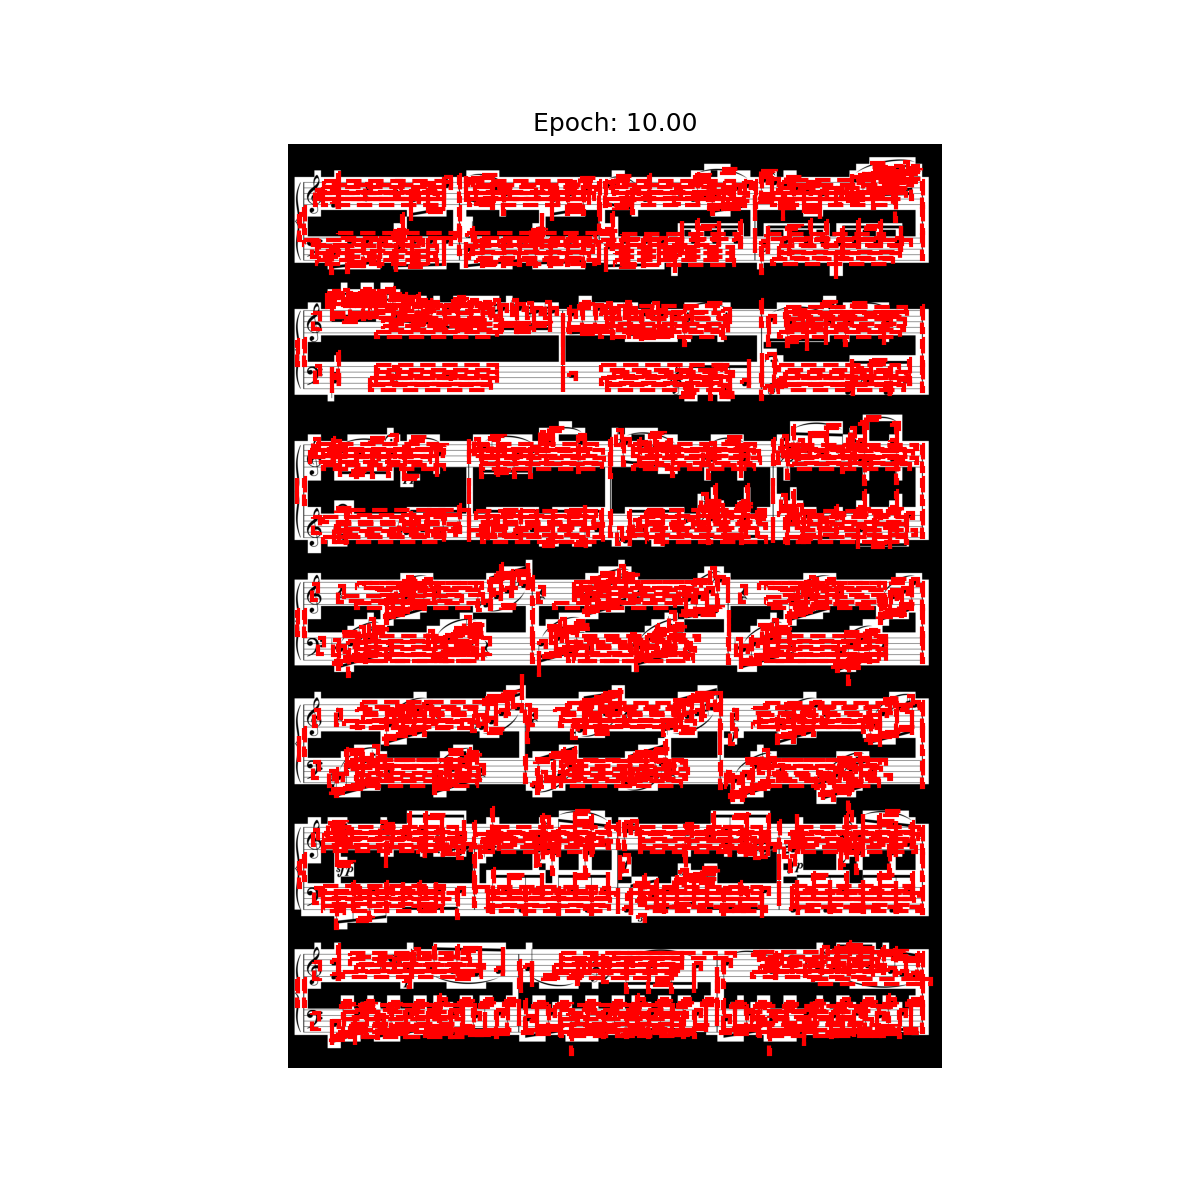

In [8]:
from IPython.display import Image, display
from pathlib import Path
files = Path("experiments/010_full_dataset_baseline/train_detection/visualizations/").glob("*")
latest_file = max([f for f in files], key=lambda item: item.stat().st_ctime)
display(Image(filename=latest_file))